# Population dynamics: how does reward training reshape the representation?

Compares the **no-reward baseline** network against the **reward-trained**
network (same seed) representation: population-vector
correlation between the two networks' spatial maps, and which cells
appear/disappear from the single-field population when reward is introduced.

This notebook demonstrates the *method* on the one available before/after
pair. 

In [1]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from prnn.utils.predictiveNet import PredictiveNet
import spatial_analysis as sa

DATA_DIR = REPO_ROOT / "data" / "trajectory"
EXAMPLES_DIR = REPO_ROOT / "figures" / "example_diagnostics"

OBS = [torch.tensor(np.load(DATA_DIR / f"obs{i}.npy")) for i in range(4)]
ACT = torch.tensor(np.load(DATA_DIR / "act.npy"))
STATE = {
    "agent_pos": torch.tensor(np.load(DATA_DIR / "pos.npy")),
    "agent_dir": torch.tensor(np.load(DATA_DIR / "dir.npy")),
    "mean_vel": 0.2,
}

wandb not installed, will not log to wandb


## 1. Compute hidden-layer place fields and cell-type classification for both networks

In [2]:
def analyze(savename):
    net = PredictiveNet.loadNet(savename, savefolder=str(REPO_ROOT) + "/", dil=False)
    env = net.EnvLibrary[0]
    place_fields, SI, WAKE = sa.calculateSpatialRepresentation(net, env, OBS, ACT, STATE, saveTrainingData=False)
    metrics = sa.calculate_metrics(env, place_fields, SI, WAKE)
    groups, groupID = sa.groupCells(metrics)
    return dict(net=net, env=env, place_fields=place_fields, groups=groups)

before = analyze("base_no_reward_s1001_ep5")     # no-reward baseline
after = analyze("random_rew_mult5_s1001_ep5")    # reward-trained, same seed

print("before: single-field =", int(before["groups"]["single_field"].sum()),
      " complex =", int(before["groups"]["complex_cells"].sum()))
print("after:  single-field =", int(after["groups"]["single_field"].sum()),
      " complex =", int(after["groups"]["complex_cells"].sum()))

Net Loaded from pathname


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(


Net Loaded from pathname


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:378: RuntimeWarning: invalid value encountered in true_divide
  fxfr = fx / fr
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:389: RuntimeWarning: invalid value encountered in true_divide
  SI = SI / fr[:, 0, 0]
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/core/utils.py:114: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'Tensor'.
  warnings.warn(
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-packages/pynapple/process/tuning_curves.py:290: Run

/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:448: RuntimeWarning: invalid value encountered in double_scalars
  border_score = (mean_border_rate - mean_nonborder_rate) / (mean_border_rate + mean_nonborder_rate)


before: single-field = 122  complex = 546
after:  single-field = 101  complex = 532


/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:501: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:501: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:510: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/prnn/analysis/TuningCurveAnalysis.py:510: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  centerlabeled = labeled == whicharea
/Users/hadrienpadilla/Documents/McGill/Peyrache Lab/pRNN/.newenv/lib/python3.9/site-

## 2. Population-vector correlation, before vs. after (shared hidden units, cell-by-cell)

population-vector correlation across 700 shared hidden units: mean=0.155, median=0.146


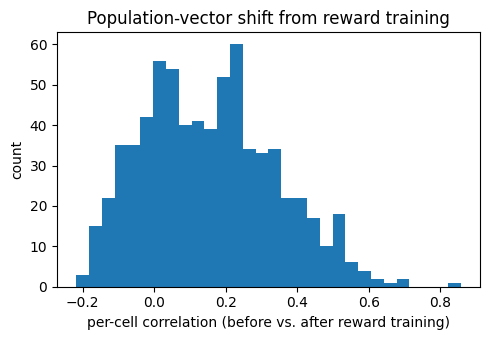

In [3]:
shared_cells = sorted(set(before["place_fields"].keys()) & set(after["place_fields"].keys()))
pv_corr = np.array([
    sa.take_correlation_2d(
        np.asarray(before["place_fields"][c]).ravel(),
        np.asarray(after["place_fields"][c]).ravel(),
    )
    for c in shared_cells
])
print(f"population-vector correlation across {len(shared_cells)} shared hidden units: "
      f"mean={np.nanmean(pv_corr):.3f}, median={np.nanmedian(pv_corr):.3f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(pv_corr[np.isfinite(pv_corr)], bins=30)
ax.set_xlabel("per-cell correlation (before vs. after reward training)")
ax.set_ylabel("count")
ax.set_title("Population-vector shift from reward training")
plt.tight_layout()
plt.show()

## 3. Which cells appear / disappear from the single-field population

single-field cells: before=122, after=101
stable=16, appearing=85, disappearing=106


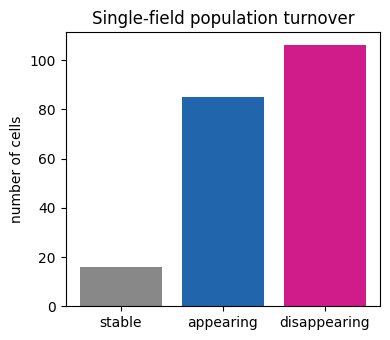

In [4]:
before_single = set(np.flatnonzero(before["groups"]["single_field"]).tolist())
after_single = set(np.flatnonzero(after["groups"]["single_field"]).tolist())

appearing = after_single - before_single    # became single-field only after reward training
disappearing = before_single - after_single  # lost single-field tuning after reward training
stable = before_single & after_single

print(f"single-field cells: before={len(before_single)}, after={len(after_single)}")
print(f"stable={len(stable)}, appearing={len(appearing)}, disappearing={len(disappearing)}")

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.bar(["stable", "appearing", "disappearing"], [len(stable), len(appearing), len(disappearing)],
       color=["#888888", "#2166ac", "#d01c8b"])
ax.set_ylabel("number of cells")
ax.set_title("Single-field population turnover")
plt.tight_layout()
plt.show()

## 4. Example diagnostics from the full-scale run

These are representative examples (not regenerated here) from the original
study's full population-dynamics sweep, one per diagnostic type — showing
what each analysis looks like across the complete set of network checkpoints
rather than just the one before/after pair above.

pv_corr_vs_base


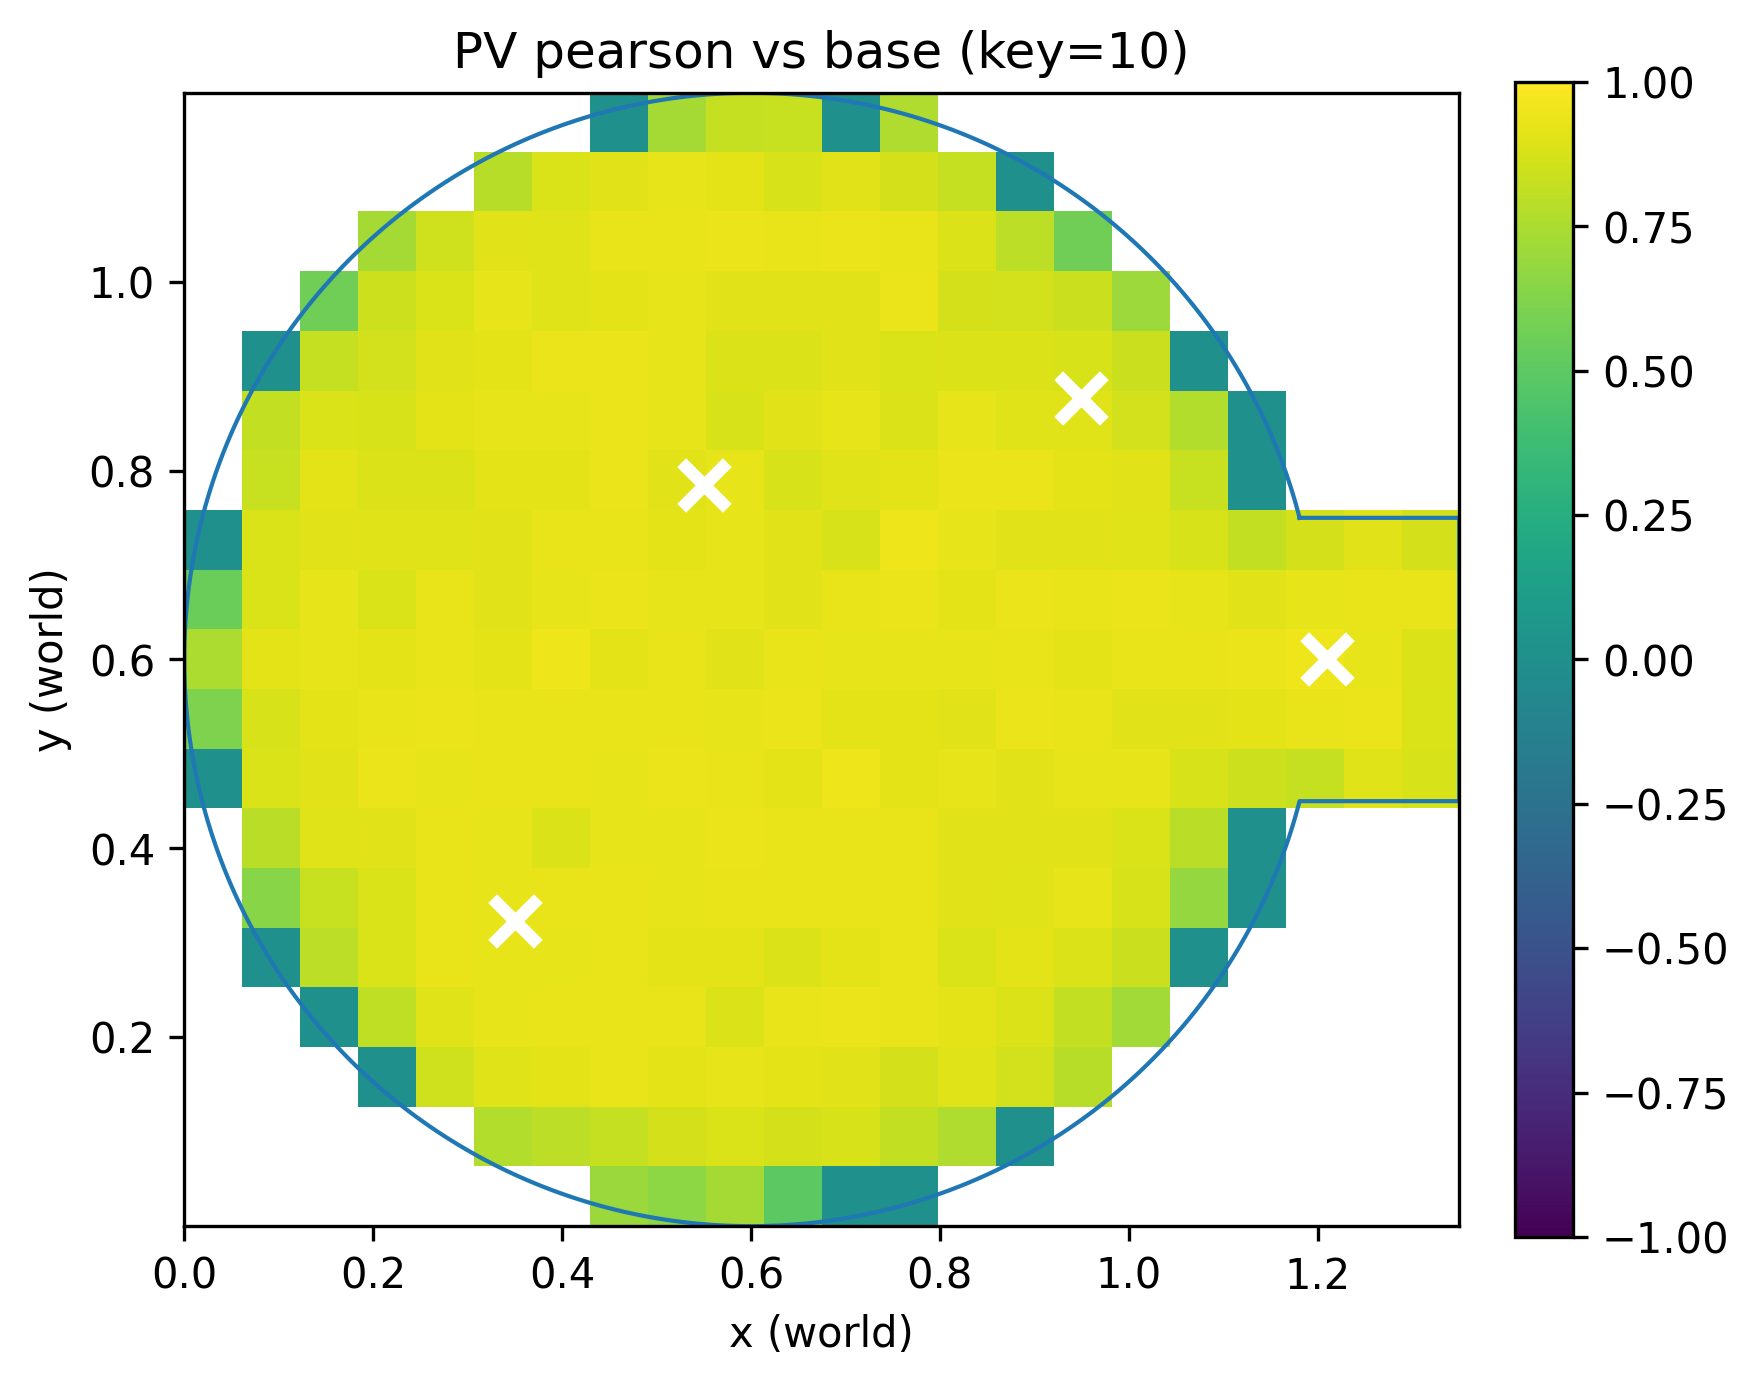

shifted_pv_corr_vs_base


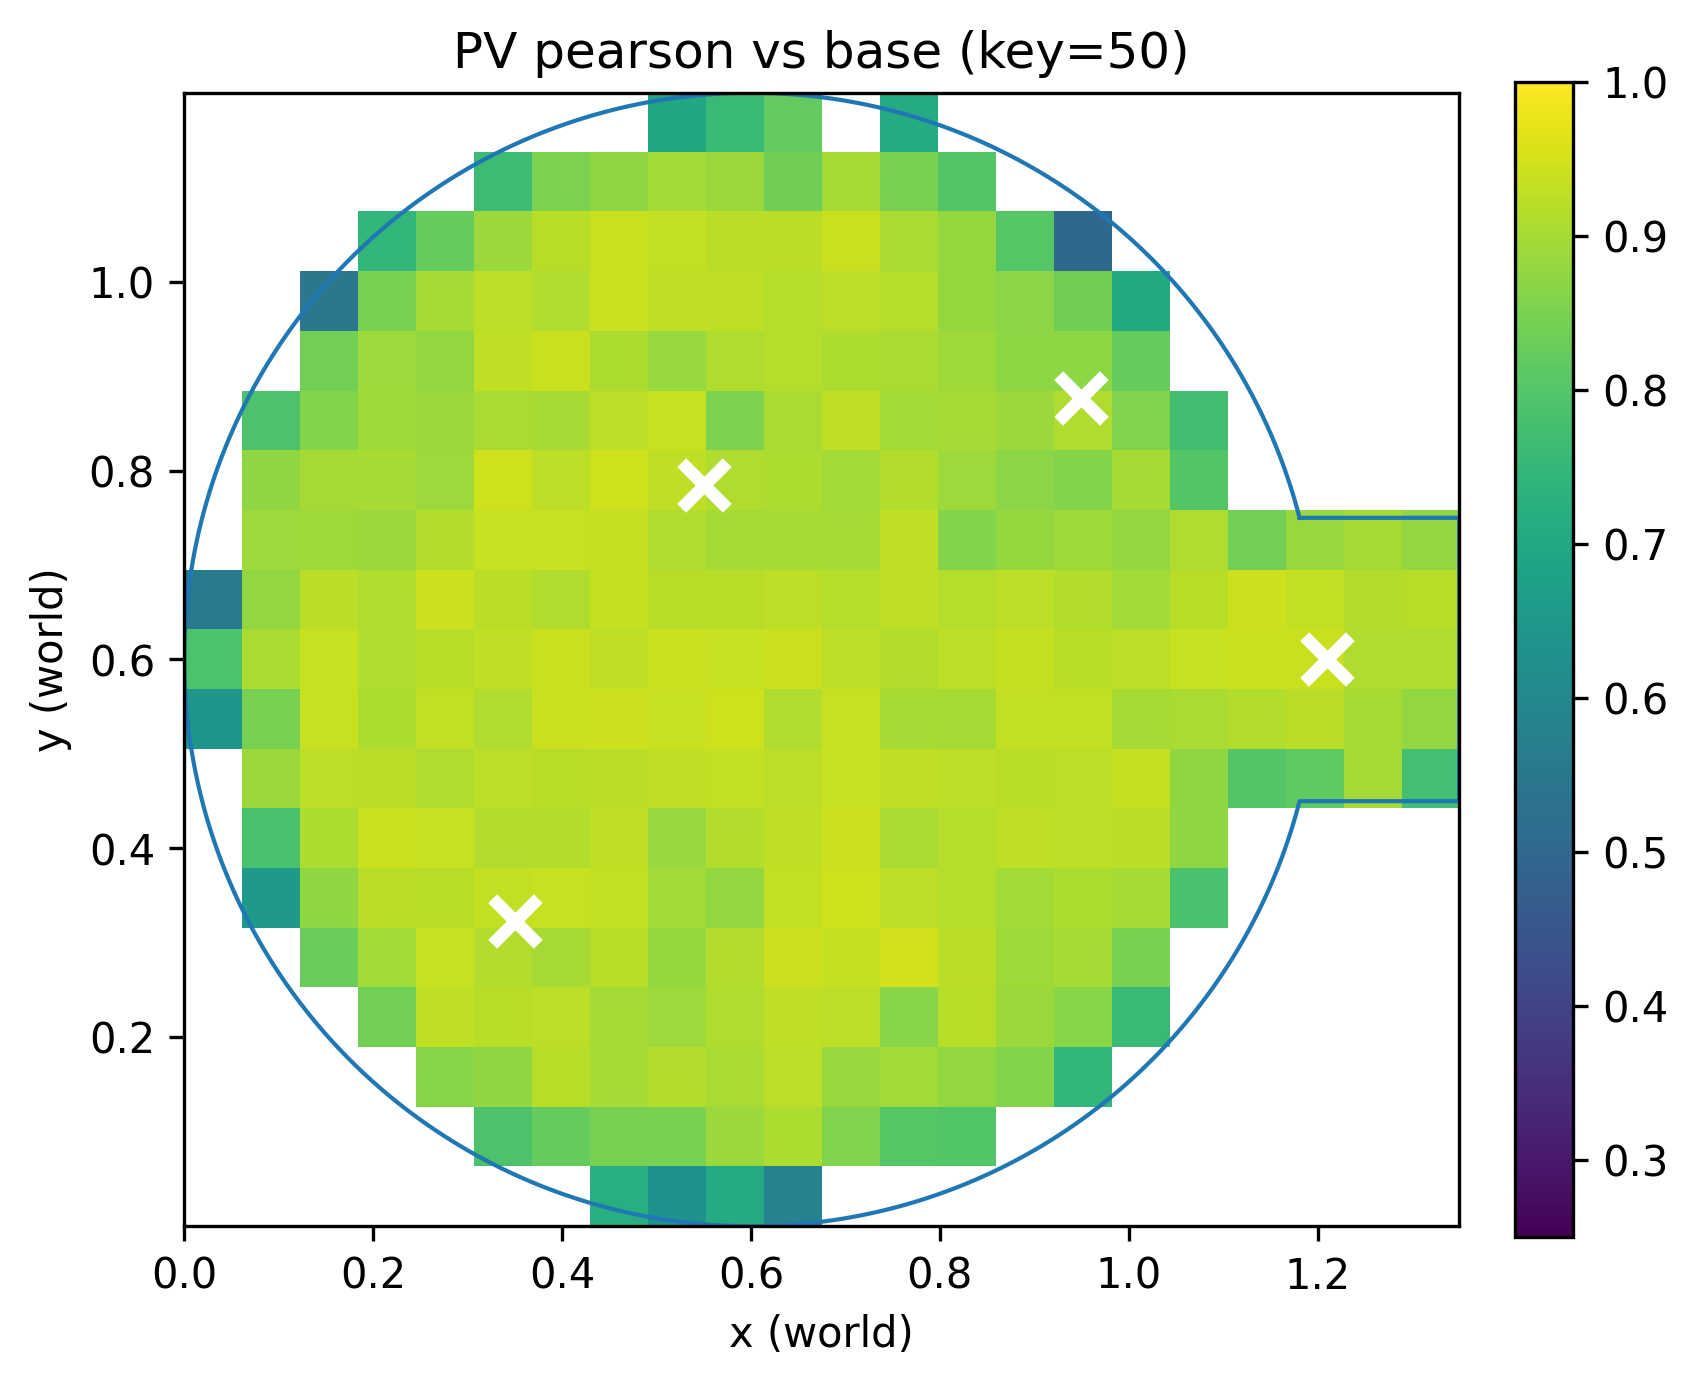

pre_post


appear_disappear


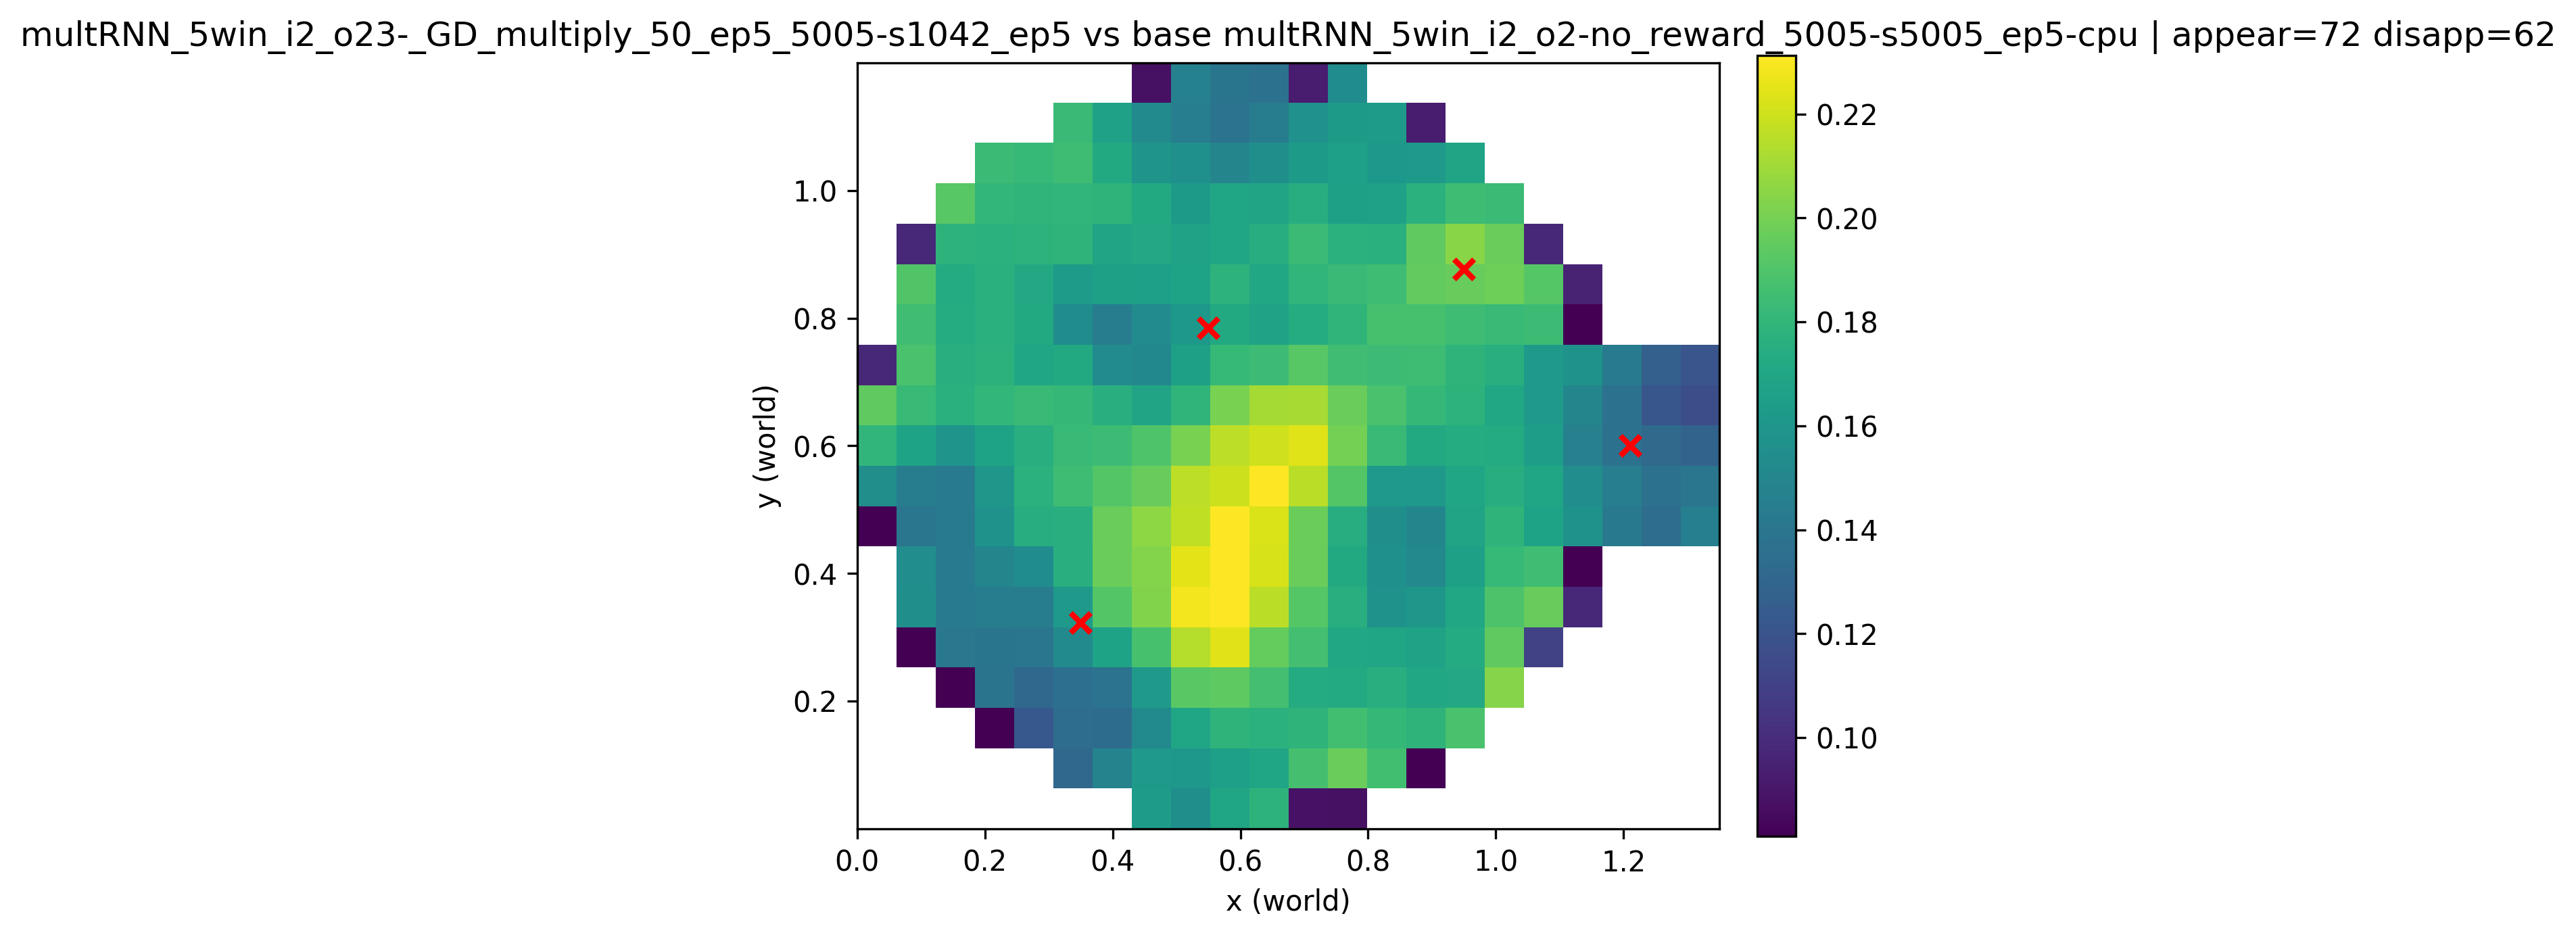

In [5]:
from IPython.display import Image, display
for name in ["pv_corr_vs_base", "shifted_pv_corr_vs_base", "pre_post", "appear_disappear"]:
    matches = list(EXAMPLES_DIR.glob(f"{name}*"))
    if matches:
        print(name)
        display(Image(filename=str(matches[0])))
    else:
        print(name, "-- no example file found")